# 1. Dataset y Estructura

Los pacientes diabéticos hospitalizados presentan tasas de readmisión elevadas. Cuando el reingreso ocurre dentro de los 30 días posteriores al alta, los sistemas de salud lo interpretan como un indicador de calidad asistencial, porque sugiere un alta prematura, una estabilización incompleta o una planificación deficiente del egreso. El objetivo del proyecto es predecir ese reingreso temprano con la información disponible en el momento del alta.

### 1.1. Dataset

- **Nombre:** Diabetes 130-US Hospitals for Years 1999-2008
- **Fuente:** [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008)
- **Tamaño:** 101,766 registros y 50 variables
- **Unidad de observación:** el **encuentro hospitalario**, no el paciente
- **Criterios de inclusión originales:** ingresos de pacientes con diagnóstico de diabetes, estancia de 1 a 14 días, con pruebas de laboratorio realizadas y medicamentos administrados durante la hospitalización
- **Archivo auxiliar:** `IDS_mapping.csv`, que traduce los tres identificadores administrativos codificados como enteros


### 1.2. Diccionario de variables

El dataset contiene variables de distinta naturaleza que permiten caracterizar a los pacientes, sus antecedentes, las condiciones clínicas y el desarrollo de la hospitalización. Para organizar estas variables, se clasifican según su **bloque temático o naturaleza** y su función dentro del problema de aprendizaje supervisado: **variables predictoras** y **variable objetivo**.

Las variables predictoras corresponden a las características utilizadas como entradas potenciales del modelo para identificar patrones asociados al reingreso hospitalario. La variable objetivo, por su parte, representa el desenlace que se busca predecir: la readmisión del paciente dentro de los 30 días posteriores al alta.

| Variable | Descripción | Bloque o naturaleza | Disponible desde |
| :--- | :--- | :--- | :--- |
| `encounter_id` | Identificador del encuentro hospitalario, asignado de forma secuencial | Administrativa | No es predictor: se elimina |
| `patient_nbr` | Identificador del paciente; se repite entre encuentros del mismo individuo | Administrativa | No es predictor: agrupa la validación |
| `race` | Raza autodeclarada | Demográfica | Ingreso |
| `gender` | Sexo registrado | Demográfica | Ingreso |
| `age` | Edad agrupada en intervalos de diez años | Demográfica | Ingreso |
| `weight` | Peso en intervalos de libras | Clínica | Ingreso |
| `admission_type_id` | Tipo de admisión: urgencia, electiva, recién nacido, entre otros | Administrativa | Ingreso |
| `discharge_disposition_id` | Destino al alta: domicilio, traslado a otra institución, fallecimiento, hospicio | Administrativa | Alta |
| `admission_source_id` | Vía de ingreso: urgencias, remisión médica, traslado desde otro centro | Administrativa | Ingreso |
| `time_in_hospital` | Días transcurridos entre el ingreso y el alta (1 a 14 por criterio de inclusión) | Proceso hospitalario | Alta |
| `payer_code` | Código del asegurador responsable del pago | Administrativa | Ingreso |
| `medical_specialty` | Especialidad del médico que admite al paciente | Administrativa | Ingreso |
| `num_lab_procedures` | Pruebas de laboratorio realizadas durante el ingreso | Proceso hospitalario | Alta |
| `num_procedures` | Procedimientos distintos de laboratorio realizados durante el ingreso | Proceso hospitalario | Alta |
| `num_medications` | Medicamentos distintos administrados durante el ingreso | Proceso hospitalario | Alta |
| `number_outpatient` | Consultas externas del paciente en el año previo al encuentro | Historial clínico | Ingreso |
| `number_emergency` | Visitas a urgencias del paciente en el año previo al encuentro | Historial clínico | Ingreso |
| `number_inpatient` | Hospitalizaciones del paciente en el año previo al encuentro | Historial clínico | Ingreso |
| `diag_1` | Diagnóstico principal, codificado en ICD-9 | Clínica | Ingreso |
| `diag_2` | Diagnóstico secundario, codificado en ICD-9 | Clínica | Alta |
| `diag_3` | Diagnóstico adicional, codificado en ICD-9 | Clínica | Alta |
| `number_diagnoses` | Número de diagnósticos registrados en el episodio | Clínica | Alta |
| `max_glu_serum` | Glucosa sérica máxima: `>200`, `>300`, `Norm` o prueba no realizada | Laboratorio | Alta |
| `A1Cresult` | Hemoglobina glicosilada: `>7`, `>8`, `Norm` o prueba no realizada | Laboratorio | Alta |
| 23 columnas de fármacos | Estado de cada antidiabético durante el ingreso: `No` (no administrado), `Steady` (dosis mantenida), `Up` (aumentada) o `Down` (reducida) | Tratamiento | Alta |
| `change` | Indica si hubo algún cambio en la medicación antidiabética | Tratamiento | Alta |
| `diabetesMed` | Indica si se administró algún medicamento antidiabético | Tratamiento | Alta |
| `readmitted` | Readmisión posterior al alta: `<30` días, `>30` días o ninguna | Desenlace | **Posterior al alta** |

Las 23 columnas de fármacos son `metformin`, `repaglinide`, `nateglinide`, `chlorpropamide`, `glimepiride`, `acetohexamide`, `glipizide`, `glyburide`, `tolbutamide`, `pioglitazone`, `rosiglitazone`, `acarbose`, `miglitol`, `troglitazone`, `tolazamide`, `examide`, `citoglipton`, `insulin`, `glyburide-metformin`, `glipizide-metformin`, `glimepiride-pioglitazone`, `metformin-rosiglitazone` y `metformin-pioglitazone`.

La columna "disponible desde" indica el momento en que el dato existe, y es la que determina qué variables son admisibles como predictores. El modelo emite su predicción en el momento del alta, de modo que las variables de proceso hospitalario son legítimas pese a generarse durante la estancia. Solo `readmitted` es posterior al alta, y por eso es el desenlace y nunca una entrada.

### 1.3. Variable objetivo

La variable `readmitted` tiene tres niveles: `<30`, `>30` y `NO`. Se derivará la variable binaria

$$
y_i = \begin{cases}
1 & \text{si el paciente } i \text{ reingresa antes de 30 días tras el alta} \\
0 & \text{en caso contrario}
\end{cases}
$$

Las readmisiones posteriores a 30 días se agrupan con los no readmitidos porque responden sobre todo a la progresión natural de una enfermedad crónica y no a la calidad del episodio analizado.

In [1]:
from config import *

## 2. Lectura de datos faltantes

El archivo usa dos convenciones distintas:

1. El carácter `?` indica un **dato ausente**. Se convierte a `NaN`.
2. El valor `None` en `A1Cresult` y `max_glu_serum` indica que **la prueba no se realizó**. No es un dato perdido: es una decisión clínica, y como tal es informativa. Se conserva como categoría.

Por defecto `pandas` interpreta la cadena `"None"` como nulo, lo que borraría esa distinción. Se desactiva ese comportamiento con `keep_default_na=False` y se declara `?` como único código de faltante.

In [2]:
crudo = pd.read_csv(
    DATOS_CRUDOS / "diabetic_data.csv",
    na_values=["?"],
    keep_default_na=False,
    low_memory=False,
)

print(f"Registros        : {crudo.shape[0]:,}")
print(f"Variables        : {crudo.shape[1]}")
print(f"Encuentros únicos: {crudo['encounter_id'].nunique():,}")
print(f"Pacientes únicos : {crudo['patient_nbr'].nunique():,}")

Registros        : 101,766
Variables        : 50
Encuentros únicos: 101,766
Pacientes únicos : 71,518


In [3]:
tabla_estilizada(
    crudo,
    filas=5,
    titulo="Vista inicial del dataset",
    indice=False
)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),nan,6,25,1,1,nan,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,nan,nan,1,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),nan,1,1,7,3,nan,nan,59,0,18,0,0,0,276,250.01,255,9,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),nan,1,1,7,2,nan,nan,11,5,13,2,0,1,648,250,V27,6,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),nan,1,1,7,2,nan,nan,44,1,16,0,0,0,8,250.43,403,7,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),nan,1,1,7,1,nan,nan,51,0,8,0,0,0,197,157,250,5,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [4]:
tabla_estilizada(
    crudo,
    filas=5,
    titulo="Últimas cinco filas",
    posicion="final"
)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
101761,443847548,100162476,AfricanAmerican,Male,[70-80),nan,1,3,7,3,MC,nan,51,0,16,0,0,0,250.13,291,458,9,None,>8,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),nan,1,4,5,5,MC,nan,33,3,18,0,0,1,560,276,787,9,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),nan,1,1,7,1,MC,nan,53,0,9,1,0,0,38,590,296,13,None,None,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),nan,2,3,7,10,MC,Surgery-General,45,2,21,0,0,1,996,285,998,9,None,None,No,No,No,No,No,No,Steady,No,No,Steady,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
101765,443867222,175429310,Caucasian,Male,[70-80),nan,1,1,7,6,nan,nan,13,3,3,0,0,0,530,530,787,9,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO


In [5]:
resumen = pd.DataFrame({
    "Variable": crudo.columns,
    "Tipo de dato": crudo.dtypes.astype(str).values,
    "Valores no nulos": crudo.notna().sum().values,
    "Valores faltantes": crudo.isna().sum().values,
    "Valores únicos": crudo.nunique().values
})

tabla(resumen, filas=15)

La tabla muestra que, del conjunto de datos, varias variables presentan una cantidad considerable de valores faltantes. Las variables con mayor ausencia de información son `weight`, con 98,569 valores faltantes, `medical_specialty`, con 49,949, y `payer_code`, con 40,256. También se observan faltantes en race, aunque en menor proporción. En cuanto a los valores únicos, diag_3 y diag_2 poseen una alta diversidad de categorías, con 789 y 748 valores únicos, respectivamente, lo que refleja la variedad de diagnósticos registrados.

Además, si bien el conjunto de datos clasifica trece variables como cuantitativas, tres de ellas (admission_type_id, discharge_disposition_id y admission_source_id) funcionan internamente como códigos categóricos.

In [6]:
tabla(
    crudo
    .select_dtypes(include="number")
    .drop(columns=[
        "encounter_id",
        "patient_nbr",
        "admission_type_id",
        "discharge_disposition_id",
        "admission_source_id"
    ])
    .describe()
    .T
    .round(2),
    filas=20
)

La tabla muestra las estadísticas descriptivas de las variables numéricas del conjunto de datos, evaluando un total de 101,766 registros sin valores faltantes en este subconjunto. Entre las métricas de tendencia central y dispersión, destaca el tiempo de estancia hospitalaria (time_in_hospital), con un promedio de 4.40 días y una mediana de 4.0 días. 

Asimismo, variables relacionadas con la actividad clínica muestran una alta variabilidad, como el número de procedimientos de laboratorio (num_lab_procedures), que promedia 43.10 con valores máximos de hasta 132.0, y el número de medicamentos (num_medications), con una media de 16.02 y un máximo de 81.0. Las variables de utilización previa (`number_outpatient`, `number_emergency` y `number_inpatient`) tienen mediana cero y máximos de 42, 76 y 21 visitas respectivamente: un patrón típico de conteos con exceso de ceros y cola larga. Estos resultados permiten comprender la distribución y el comportamiento de las variables cuantitativas.

### 2.1. Rangos y valores imposibles

Se verifica que ninguna variable numérica contenga valores lógicamente inadmisibles, ni códigos centinela del tipo 999 o 9999 que suelen usarse para marcar ausencias.

In [7]:
NUMERICAS_CRUDAS = [
    "time_in_hospital", "num_lab_procedures", "num_procedures",
    "num_medications", "number_outpatient", "number_emergency",
    "number_inpatient", "number_diagnoses",
]

rangos = pd.DataFrame({
    "mínimo": crudo[NUMERICAS_CRUDAS].min(),
    "máximo": crudo[NUMERICAS_CRUDAS].max(),
    "negativos": (crudo[NUMERICAS_CRUDAS] < 0).sum(),
    "posibles centinelas (999 / 9999)": [
        crudo[c].isin([999, 9999, 99999]).sum() for c in NUMERICAS_CRUDAS
    ],
})
rangos

,mínimo,máximo,negativos,posibles centinelas (999 / 9999)
time_in_hospital,1,14,0,0
num_lab_procedures,1,132,0,0
num_procedures,0,6,0,0
num_medications,1,81,0,0
number_outpatient,0,42,0,0
number_emergency,0,76,0,0
number_inpatient,0,21,0,0
number_diagnoses,1,16,0,0


No hay valores negativos ni códigos centinela. `time_in_hospital` va de 1 a 14 días, coherente con los criterios de inclusión declarados por los autores del dataset, y el resto de rangos es clínicamente plausible. A diferencia de otros conjuntos administrativos, aquí no se requiere limpieza de valores imposibles.

## 3. Diccionario de identificadores administrativos

`IDS_mapping.csv` apila tres tablas en un solo archivo, separadas por líneas vacías.

In [8]:
def cargar_mapeo_ids(ruta):
    """Separa las tres tablas apiladas en IDS_mapping.csv.

    El archivo contiene, en secuencia, la traducción de admission_type_id,
    discharge_disposition_id y admission_source_id, cada una precedida por su
    propia línea de encabezado y separada por una línea vacía.

    Parameters
    ----------
    ruta : str or pathlib.Path
        Ruta al archivo IDS_mapping.csv.

    Returns
    -------
    dict
        Diccionario {nombre_columna: {código: descripción}}.
    """
    mapeos, clave = {}, None
    for linea in Path(ruta).read_text(encoding="utf-8").splitlines():
        linea = linea.strip()
        if not linea or linea == ",":
            continue
        if linea.endswith("_id,description"):
            clave = linea.split(",")[0]
            mapeos[clave] = {}
            continue
        codigo, _, descripcion = linea.partition(",")
        if clave is not None and codigo.isdigit():
            mapeos[clave][int(codigo)] = descripcion.strip('"')
    return mapeos


mapeos = cargar_mapeo_ids(DATOS_CRUDOS / "IDS_mapping.csv")

for columna, traduccion in mapeos.items():
    sin_descripcion = set(crudo[columna].unique()) - set(traduccion)
    print(f"{columna}: {len(traduccion)} códigos definidos, "
          f"{len(sin_descripcion)} sin descripción en los datos")

admission_type_id: 8 códigos definidos, 0 sin descripción en los datos
discharge_disposition_id: 30 códigos definidos, 0 sin descripción en los datos
admission_source_id: 25 códigos definidos, 0 sin descripción en los datos


In [9]:
def resumen_id(columna):
    """Frecuencia y descripción de un identificador administrativo.

    Returns
    -------
    pandas.DataFrame
        Ordenado de mayor a menor frecuencia, con la traducción del código.
    """
    resumen = crudo[columna].value_counts().rename("encuentros").to_frame()
    resumen["%"] = (100 * resumen["encuentros"] / len(crudo)).round(2)
    resumen["descripción"] = [mapeos[columna][i] for i in resumen.index]
    return resumen[["descripción", "encuentros", "%"]]

In [10]:
resumen_alta = resumen_id("discharge_disposition_id")
tabla(resumen_alta, filas=30)

La tabla de destinos al alta revela seis categorías incompatibles con una readmisión posterior: los códigos 11, 19, 20 y 21 corresponden a fallecimiento y los códigos 13 y 14 a cuidados paliativos.

In [11]:
tabla(resumen_id("admission_type_id"), filas=15)

La tabla muestra la distribución de los tipos de admisión hospitalaria, revelando que más de la mitad de los encuentros corresponden a ingresos de emergencia, con 53,990 registros que representan el 53.05% del total. Le siguen en frecuencia las admisiones de tipo electivo con 18,869 casos (18.54%) y las urgentes con 18,480 casos (18.16%). Asimismo, se identifican categorías asociadas a datos no especificados o faltantes, como valores nulos y "Not Available", que agrupan el 5.20% y el 4.70% de las observaciones respectivamente, mientras que categorías minoritarias como "Not Mapped", "Trauma Center" y "Newborn" suman en conjunto menos del 0.35% de los registros.

In [12]:
tabla(resumen_id("admission_source_id"), filas=20)

La fuente de admisión concentra los encuentros en Emergency Room (56.5 %) y Physician Referral (29.1 %), con una cola de doce vías de ingreso por debajo del 1 % cada una (traslados entre instituciones, remisión legal, partos).

## 4. Calidad de datos

### 4.1. Duplicados y dependencia entre observaciones

El problema estructural más importante de este dataset no son los faltantes, sino que las filas no son independientes.

encounter_id duplicados        : 0


Filas íntegramente duplicadas : 0

Pacientes únicos                    : 71,518
Pacientes con más de un encuentro   : 16,773 (23.45 %)
Máximo de encuentros de un paciente : 40


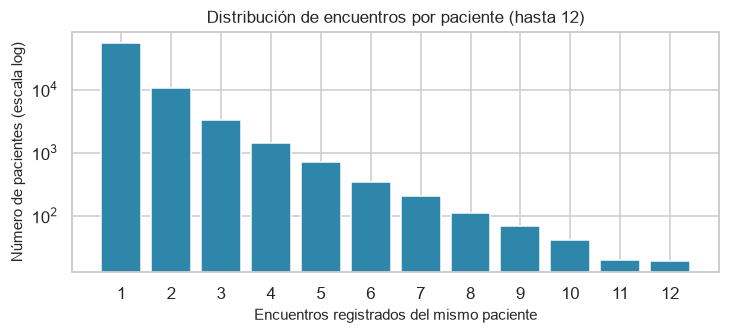

In [13]:
print(f"encounter_id duplicados        : {crudo['encounter_id'].duplicated().sum()}")
print(f"Filas íntegramente duplicadas : {crudo.duplicated().sum()}")

encuentros_por_paciente = crudo["patient_nbr"].value_counts()
print(f"\nPacientes únicos                    : "
      f"{crudo['patient_nbr'].nunique():,}")
print(f"Pacientes con más de un encuentro   : "
      f"{(encuentros_por_paciente > 1).sum():,} "
      f"({100 * (encuentros_por_paciente > 1).mean():.2f} %)")
print(f"Máximo de encuentros de un paciente : {encuentros_por_paciente.max()}")

distribucion = encuentros_por_paciente.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6.8, 3.2))
ax.bar(distribucion.index[:12], distribucion.values[:12], color=PALETA[0])
ax.set_yscale("log")
ax.set_xlabel("Encuentros registrados del mismo paciente")
ax.set_ylabel("Número de pacientes (escala log)")
ax.set_title("Distribución de encuentros por paciente (hasta 12)")
ax.set_xticks(range(1, 13))
plt.tight_layout()
plt.show()

No hay duplicación en sentido estricto: `encounter_id` es único y no existen filas repetidas. Pero casi uno de cada cuatro pacientes aparece más de una vez, y un paciente llega a registrar hasta 40 encuentros.

Esto tiene una consecuencia directa sobre la validación. Si los encuentros de un mismo paciente se reparten entre entrenamiento y prueba, el modelo puede memorizar rasgos del paciente concreto en lugar de aprender el mecanismo clínico, y la métrica quedaría inflada. Es fuga de información por dependencia de grupo.

Para comprobar que el riesgo es real se ordenan los encuentros de cada paciente y se calcula la tasa de readmisión según la posición del encuentro.

El dataset no incluye fechas de ingreso. Se asume que `encounter_id` es creciente en el tiempo, supuesto habitual en la literatura sobre este conjunto porque el identificador se asigna de forma secuencial al registrar el episodio. El supuesto afecta únicamente al orden de los encuentros de cada paciente, y con él a la tabla por posición de la sección 4.1.

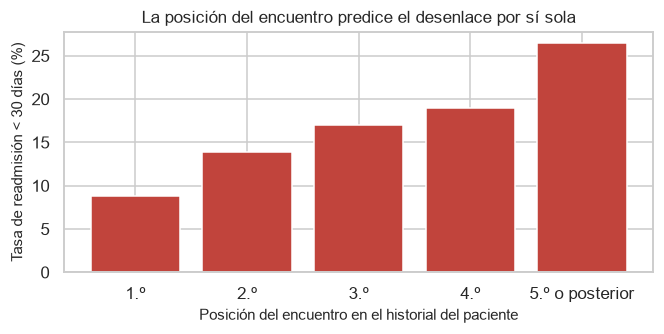

,encuentros,tasa readmisión < 30 días (%)
1.º,71518,8.80
2.º,16773,13.87
3.º,6339,16.99
4.º,3011,18.96
5.º o posterior,4125,26.42


In [14]:
posicion = crudo.sort_values("encounter_id").groupby("patient_nbr").cumcount()

tasa_por_posicion = (
    crudo.assign(posicion=posicion.clip(upper=4),
                 y=(crudo["readmitted"] == "<30").astype(int))
         .groupby("posicion")["y"].agg(["size", "mean"])
)
tasa_por_posicion.index = ["1.º", "2.º", "3.º", "4.º", "5.º o posterior"]
tasa_por_posicion.columns = ["encuentros", "tasa readmisión < 30 días (%)"]
tasa_por_posicion["tasa readmisión < 30 días (%)"] = (
    100 * tasa_por_posicion["tasa readmisión < 30 días (%)"]
).round(2)

fig, ax = plt.subplots(figsize=(6.2, 3.2))
ax.bar(tasa_por_posicion.index, tasa_por_posicion["tasa readmisión < 30 días (%)"],
       color=PALETA[1])
ax.set_ylabel("Tasa de readmisión < 30 días (%)")
ax.set_xlabel("Posición del encuentro en el historial del paciente")
ax.set_title("La posición del encuentro predice el desenlace por sí sola")
plt.tight_layout()
plt.show()

tasa_por_posicion

La tasa de readmisión temprana crece de forma monótona con el número de encuentros previos: del 8.80 % en el primer encuentro al 26.42 % a partir del quinto. Es decir, la posición del encuentro en el historial del paciente es por sí sola un predictor fuerte del desenlace.

Un modelo entrenado con todos los encuentros y validado sin agrupar por paciente aprendería parcialmente a reconocer pacientes frecuentes ya vistos, en lugar del riesgo clínico de un paciente nuevo.

### 4.2. Valores faltantes

El análisis se hace sobre los datos **crudos**, porque es la evidencia que fundamenta qué columnas eliminar y cómo tratar el resto.

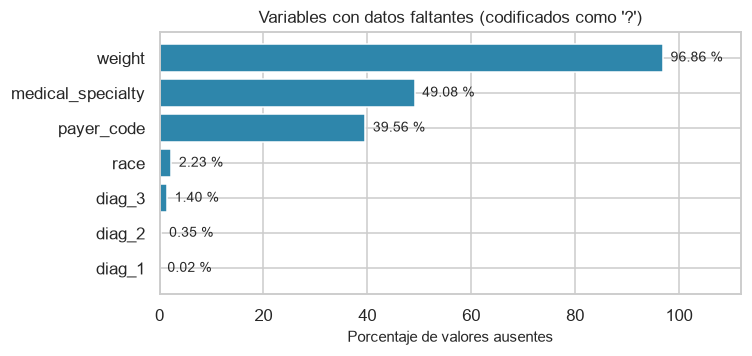

,n_faltantes,%
weight,98569,96.86
medical_specialty,49949,49.08
payer_code,40256,39.56
race,2273,2.23
diag_3,1423,1.40
diag_2,358,0.35
diag_1,21,0.02


In [15]:
faltantes = pd.DataFrame({
    "n_faltantes": crudo.isna().sum(),
    "%": (100 * crudo.isna().mean()).round(2),
}).query("n_faltantes > 0").sort_values("%", ascending=False)

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.barh(faltantes.index[::-1], faltantes["%"][::-1], color=PALETA[0])
for i, valor in enumerate(faltantes["%"][::-1]):
    ax.text(valor + 1.5, i, f"{valor:.2f} %", va="center", fontsize=9)
ax.set_xlim(0, 112)
ax.set_xlabel("Porcentaje de valores ausentes")
ax.set_title("Variables con datos faltantes (codificados como '?')")
plt.tight_layout()
plt.show()

faltantes

In [16]:
# Segunda convención: "None" indica prueba no realizada, no dato ausente.
pruebas = pd.DataFrame({
    "no medida ('None') %": [
        100 * (crudo["A1Cresult"] == "None").mean(),
        100 * (crudo["max_glu_serum"] == "None").mean(),
    ],
    "medida %": [
        100 * (crudo["A1Cresult"] != "None").mean(),
        100 * (crudo["max_glu_serum"] != "None").mean(),
    ],
}, index=["A1Cresult", "max_glu_serum"]).round(2)
pruebas

,no medida ('None') %,medida %
A1Cresult,83.28,16.72
max_glu_serum,94.75,5.25


Siete variables presentan faltantes reales, con perfiles muy distintos: `weight` (96.86 %), `medical_specialty` (49.08 %), `payer_code` (39.56 %), `race` (2.23 %) y los tres códigos diagnósticos con ausencias marginales (entre 0.02 % y 1.40 %).

La hemoglobina glicosilada no se midió en el 83 % de los encuentros y la glucosa sérica en el 95 %. Estos valores **no se cuentan como faltantes**, por la razón explicada en la sección 2.

### 4.3. ¿Son aleatorias las ausencias?

La pregunta relevante no es cuántos faltantes hay, sino si su ausencia guarda relación con el desenlace, porque de eso depende el tratamiento correcto. Se contrasta la independencia entre el indicador de faltante y la variable objetivo.

Para determinar si la ausencia de información en las variables con valores faltantes responde a un patrón completamente aleatorio o si guarda relación con el desenlace clínico, se llevó a cabo un contraste de independencia entre el indicador de nulos y la variable objetivo (readmisión a 30 días). Dado el gran volumen de observaciones del dataset, la evaluación combinó pruebas de hipótesis (Chi-cuadrado y Fisher) con la corrección de p-valores por el método de Holm, complementadas con el análisis de la diferencia de tasas como tamaño del efecto.

Conviene precisar qué se está probando. Este contraste **no es una prueba de MCAR**: evalúa si la ausencia es independiente del desenlace. Rechazarlo es evidencia contra el supuesto de ausencia completamente aleatoria, pero no lo prueba en sentido estricto, ya que la ausencia podría depender de variables observadas. Además, con n superior a 100,000 cualquier diferencia mínima resulta significativa, de modo que se reporta también la diferencia de tasas como tamaño del efecto.

In [17]:
def correccion_holm(valores_p):
    """Corrección de Holm-Bonferroni para comparaciones múltiples.

    Controla la tasa de error familiar de forma menos conservadora que
    Bonferroni, manteniendo validez sin supuestos sobre la dependencia
    entre contrastes.

    Parameters
    ----------
    valores_p : array_like
        Valores p sin corregir.

    Returns
    -------
    numpy.ndarray
        Valores p ajustados, monótonos y acotados en 1.
    """
    p = np.asarray(valores_p, dtype=float)
    m = len(p)
    orden = np.argsort(p)
    ajustados = np.empty(m)
    maximo = 0.0
    for i, indice in enumerate(orden):
        maximo = max(maximo, (m - i) * p[indice])
        ajustados[indice] = min(1.0, maximo)
    return ajustados


y_crudo = (crudo["readmitted"] == "<30").astype(int)

filas = []
for columna in faltantes.index:
    indicador = crudo[columna].isna().astype(int)
    contingencia = pd.crosstab(indicador, y_crudo)
    chi2, p, _, esperadas = stats.chi2_contingency(contingencia)
    # Con frecuencias esperadas pequeñas la aproximación chi² no es válida:
    # se usa la prueba exacta de Fisher, apropiada en tablas 2x2.
    prueba = "chi²"
    if esperadas.min() < 5:
        p = stats.fisher_exact(contingencia).pvalue
        prueba = "Fisher exacto"
    filas.append({
        "variable": columna,
        "% faltante": 100 * indicador.mean(),
        "prueba": prueba,
        "chi²": chi2,
        "p": p,
        "mín. frecuencia esperada": esperadas.min(),
        "tasa si falta (%)": 100 * y_crudo[indicador == 1].mean(),
        "tasa si está (%)": 100 * y_crudo[indicador == 0].mean(),
    })

nulidad = pd.DataFrame(filas).set_index("variable")
nulidad["p (Holm)"] = correccion_holm(nulidad["p"])
nulidad["diferencia (pp)"] = (
    nulidad["tasa si falta (%)"] - nulidad["tasa si está (%)"]
)
nulidad["¿independiente? (α=0.05)"] = np.where(
    nulidad["p (Holm)"] > 0.05, "Sí", "No"
)
tabla(nulidad.round(4), filas=10)

`weight` es el caso extremo de independencia (χ² nulo, p = 1.00): su ausencia no guarda relación con la readmisión, lo que refuerza eliminarla sin más consideraciones. Esto no demuestra que su ausencia sea completamente aleatoria, porque podría depender de otras variables observadas. En cambio, `medical_specialty`, `payer_code`, `race` y `diag_3` rechazan la independencia tras la corrección de Holm, con efectos moderados: entre 0.55 y 4.83 puntos porcentuales de diferencia en la tasa de readmisión. `diag_1` y `diag_2` no la rechazan. Donde la ausencia es informativa y la variable se conserva, se codifica como categoría explícita (sección 5, fila 10). `payer_code` se elimina de todas formas, porque describe al asegurador y no el estado clínico.

- **Matriz de nulidad**:

Para examinar de forma visual la distribución y posibles patrones estructurales de los valores faltantes, se generó una matriz de nulidad a partir de una muestra aleatoria de 2,000 encuentros.

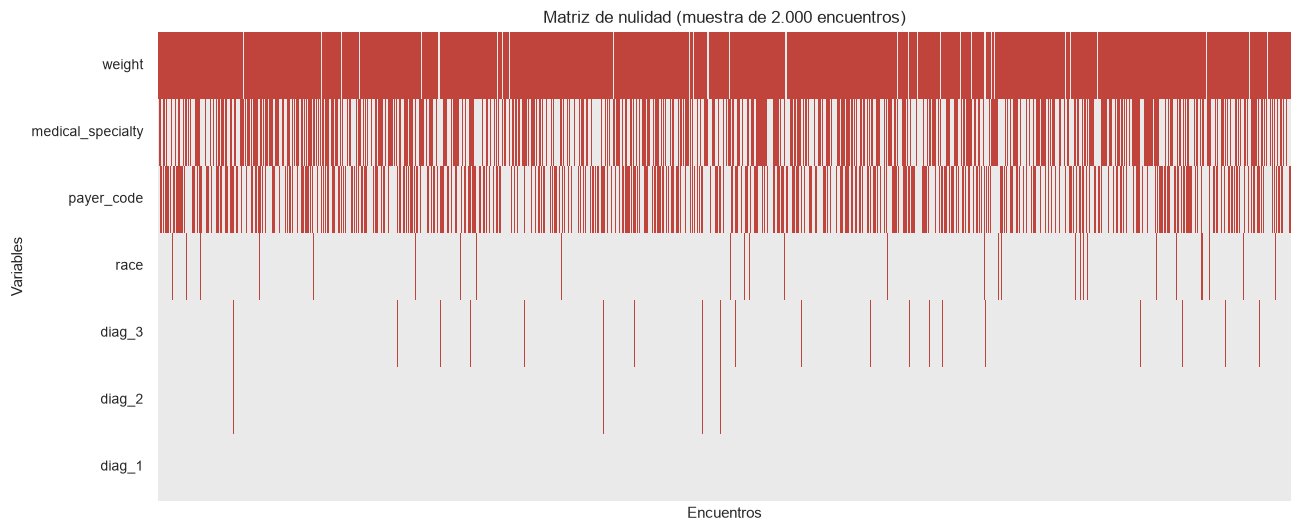

In [18]:
columnas_con_faltantes = faltantes.index.tolist()
indicadores = crudo[columnas_con_faltantes].isna().astype(int)

muestra = indicadores.sample(
    2000,
    random_state=RANDOM_STATE
)

plt.figure(figsize=(12, 5))

sns.heatmap(
    muestra.T,
    cbar=False,
    cmap=["#EAEAEA", PALETA[1]],
    yticklabels=True,
    xticklabels=False
)

plt.title("Matriz de nulidad (muestra de 2.000 encuentros)")
plt.xlabel("Encuentros")
plt.ylabel("Variables")
plt.tick_params(axis="y", labelsize=9, rotation=0)

plt.tight_layout()
plt.show()

En el mapa de calor binario —donde el color rojo representa la ausencia del dato y el gris claro su presencia— se corrobora gráficamente la elevada densidad de nulos en la variable weight, la cual carece de registros en la gran mayoría de las observaciones. De igual manera, las variables medical_specialty y payer_code evidencian una pérdida de datos amplia y dispersa a lo largo del conjunto de registros. Por el contrario, los campos correspondientes a race, diag_3, diag_2 y diag_1 muestran ausencias puntuales y muy esporádicas, lo que confirma visualmente su alta completitud y descarta la existencia de bloques sistemáticos de información faltante en dichas variables clínicas.

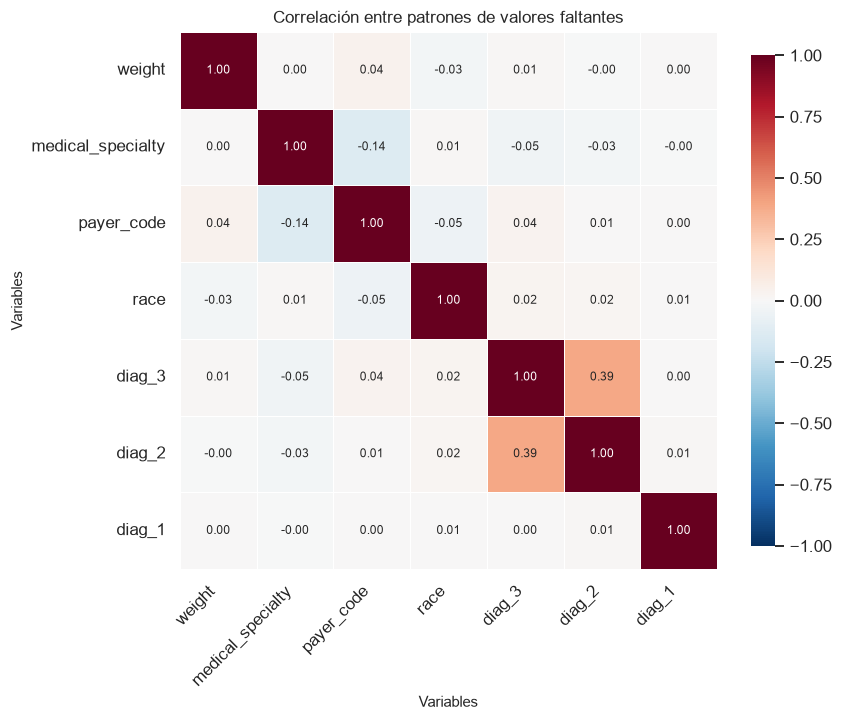

In [19]:
correlacion_nulidad = indicadores.corr()

plt.figure(figsize=(8, 7))

sns.heatmap(
    correlacion_nulidad,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.4,
    annot_kws={"size": 8},
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlación entre patrones de valores faltantes")
plt.xlabel("Variables")
plt.ylabel("Variables")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

- **Matriz de correlación**:

Esta métrica cuantifica en qué medida la ausencia de un dato en una columna coincide con la ausencia en otra. Los resultados revelan una independencia casi absoluta entre la mayoría de las variables principales (con coeficientes cercanos a 0.00 entre weight, medical_specialty, payer_code y race), lo que descarta la presencia de bloques masivos o pérdidas simultáneas de registros debidas a fallos sistémicos u operativos en el registro clínico. La única excepción es la correlación de 0.39 entre `diag_2` y `diag_3`: los pacientes con pocos diagnósticos registrados carecen de ambos a la vez. En el resto de los pares los coeficientes son cercanos a cero, de modo que no conviene resumir varias ausencias en un único indicador. Esta independencia entre variables es distinta de la relación de cada ausencia con el desenlace, analizada en la sección anterior.

### 4.4. Variables constantes y cuasi constantes

Una variable sin varianza no aporta capacidad discriminante, encarece la codificación y puede producir columnas vacías al aplicar `OneHotEncoder` dentro de un fold de validación.

In [20]:
varianza = pd.DataFrame({
    "categorías": crudo.nunique(),
    "moda": crudo.apply(lambda s: s.value_counts(dropna=False).index[0]),
    "% moda": (100 * crudo.apply(
        lambda s: s.value_counts(dropna=False, normalize=True).iloc[0])).round(3),
})
cuasi_constantes = varianza.query("`% moda` > 95").sort_values(
    "% moda", ascending=False)
tabla(cuasi_constantes, filas=20)

Diecisiete columnas superan el 95 % de concentración en una sola categoría: dieciséis fármacos y `weight`, cuyo caso se trata aparte por ser un problema de faltantes y no de varianza.

La concentración relativa no sirve como criterio de eliminación: `repaglinide` tiene el 98.5 % de sus registros en `No` y aun así más de mil quinientos encuentros con variación, suficientes para estimar un efecto. El criterio adecuado es el **número de encuentros con variación**, y el capítulo 2 lo aplica con un umbral de veinticinco, justificado allí con una medición del costo computacional que introducen las columnas casi vacías.

Conviene además precisar la varianza real de estas variables sobre el crudo: solo `examide` y `citoglipton` son estrictamente constantes. `acetohexamide`, `glimepiride-pioglitazone` y `metformin-pioglitazone` registran un caso, `metformin-rosiglitazone` dos y `troglitazone` tres, casos que desaparecen al aplicar las exclusiones clínicas del capítulo 2.

### 4.5. Cardinalidad

Las variables con muchas categorías generan matrices dispersas al codificarse y elevan el riesgo de sobreajuste, sobre todo cuando algunas categorías tienen muy pocos casos.

In [21]:
categoricas_crudas = columnas_texto(crudo)
cardinalidad = pd.DataFrame({
    "categorías": crudo[categoricas_crudas].nunique(),
    "% moda": (100 * crudo[categoricas_crudas].apply(
        lambda s: s.value_counts(normalize=True).iloc[0])).round(2),
}).sort_values("categorías", ascending=False)
tabla(cardinalidad, filas=15)

El principal desafío de alta dimensionalidad se concentra en los tres códigos diagnósticos (diag_1, diag_2 y diag_3), los cuales presentan entre 716 y 789 categorías cada uno. Aplicar una codificación directa (one-hot encoding) generaría más de 2,000 columnas binarias, con una alta dispersión y categorías de baja frecuencia. Para mitigar este problema, la aproximación estándar en la literatura de este conjunto de datos consiste en agruparlos bajo los capítulos clínicos de la clasificación ICD-9. 

Por otro lado, la variable medical_specialty, que cuenta con 72 categorías, plantea un reto de menor complejidad que se resuelve agrupando aquellas especialidades de baja incidencia en una categoría general.

### 4.6. Valores inválidos y códigos no informativos

Además de los faltantes explícitos, el dataset contiene categorías que equivalen a información ausente pero están codificadas como valores válidos.

In [22]:
# Distribución de la variable gender
distribucion_gender = (
    crudo["gender"]
    .value_counts(dropna=False)
    .rename_axis("Categoría")
    .reset_index(name="Encuentros")
)

distribucion_gender["Porcentaje (%)"] = (
    100 * distribucion_gender["Encuentros"] / len(crudo)
).round(2)

tabla(
    distribucion_gender,
    filas=10,
    titulo="Distribución de género"
)

### Distribución de género

In [23]:
NO_INFORMATIVOS = {
    "admission_type_id": [5, 6, 8],             # Not Available, NULL, Not Mapped
    "discharge_disposition_id": [18, 25, 26],   # NULL, Not Mapped, Unknown/Invalid
    "admission_source_id": [9, 15, 17, 20, 21],
}

resultados_no_informativos = []

for columna, codigos in NO_INFORMATIVOS.items():

    # Algunos códigos están definidos en el diccionario pero no aparecen en los
    # datos: se filtran para no listar categorías que nadie tiene.
    presentes = [c for c in codigos if (crudo[columna] == c).any()]
    mascara = crudo[columna].isin(presentes)

    # Las etiquetas del diccionario de IDs traen espacios sobrantes.
    etiquetas = [
        str(mapeos[columna].get(codigo, f"Código {codigo}")).strip()
        for codigo in presentes
    ]

    resultados_no_informativos.append({
        "Variable": columna,
        "Códigos": ", ".join(map(str, presentes)),
        "Categorías": "; ".join(etiquetas),
        "Encuentros": int(mascara.sum()),
        "Porcentaje (%)": round(100 * mascara.mean(), 2)
    })

resumen_no_informativos = pd.DataFrame(resultados_no_informativos)

tabla(
    resumen_no_informativos,
    filas=10,
    titulo="Proporción de códigos administrativos no informativos",
    indice=False
)

### Proporción de códigos administrativos no informativos

Tres registros tienen `gender` igual a `Unknown/Invalid`. Se eliminan: el volumen es despreciable y no justifica crear una categoría.

Como detalla la tabla anterior, `admission_type_id` concentra 10,396 registros (10.22 %) bajo códigos equivalentes a ausencia de información (Not Available, NULL, Not Mapped). De manera similar, `admission_source_id` acumula 7,067 encuentros (6.94 %) y `discharge_disposition_id` registra 4,680 (4.60 %). Aquí el volumen sí es relevante, de modo que **no se eliminan filas**: esos códigos se conservan como categoría explícita, dado que la ausencia de registro administrativo puede correlacionar con el tipo de institución o con la vía de ingreso.

## 5. Plan de depuración

| # | Decisión | Alcance | Evidencia que la respalda |
|---|---|---|---|
| 1 | Excluir altas por fallecimiento u hospicio (códigos 11, 13, 14, 19, 20, 21) | 2,423 filas | Sección 3: el desenlace es imposible por construcción, no por riesgo clínico |
| 2 | Excluir registros con `gender = Unknown/Invalid` | 3 filas | Sección 4.6: volumen despreciable |
| 3 | Conservar todos los encuentros y agrupar la validación por `patient_nbr` | Ninguna fila descartada | Sección 4.1: los encuentros de un paciente no son independientes, pero descartar episodios introduce sesgo de selección. El capítulo 2 cuantifica las cuatro alternativas |
| 4 | Eliminar `weight` | 1 columna | Sección 4.2: 96.9 % de faltantes; imputar generaría un valor sintético para casi toda la muestra. Su ausencia es además independiente del desenlace (sección 4.3) |
| 5 | Eliminar `payer_code` | 1 columna | Sección 4.2: 39.6 % de faltantes en una variable del asegurador que no describe el estado clínico |
| 6 | Eliminar `encounter_id` | 1 columna | Identificador sin contenido clínico |
| 7 | Eliminar los fármacos con menos de veinticinco encuentros de variación | 9 columnas | Sección 4.4: la concentración relativa no basta como criterio; el capítulo 2 fija el umbral con una medición del costo que introducen las columnas casi vacías |
| 8 | Agrupar los tres códigos ICD-9 por capítulo clínico | 3 columnas | Sección 4.5: cardinalidad de 716 a 789 categorías |
| 9 | Agrupar en `"Otro"` toda categoría con menos del 1 % de los casos, en todas las variables categóricas salvo `race` | 26 columnas | Secciones 4.5 y 4.6: las categorías con muy pocos casos desestabilizan la codificación y violan los supuestos de la prueba chi-cuadrado. `race` queda exenta porque sus categorías ya cumplen los supuestos y agrupar un grupo demográfico minoritario lo eliminaría del análisis de equidad |
| 10 | Categoría explícita: `"No informada"` para `race` y `"No registrada"` para la especialidad médica | 2 columnas | Sección 4.3: la ausencia no es aleatoria y es potencialmente informativa. En el caso de `race` se añade una razón ética: imputar un atributo protegido equivale a fabricar la pertenencia a un grupo |
| 11 | Convertir los tres identificadores administrativos a tipo categórico | 3 columnas | Sección 2: son códigos nominales sin significado ordinal |
| 12 | Derivar `readmitted_30` y eliminar `readmitted` | 1 columna | Sección 1.2 |

### 5.1. Síntesis

| Dimensión | Hallazgo |
|---|---|
| Volumen | 101,766 encuentros, 71,518 pacientes, 50 variables |
| Dependencia entre filas | 23.45 % de los pacientes tiene más de un encuentro; la tasa de readmisión crece del 8.80 % al 26.42 % con la posición del encuentro |
| Convenciones de faltante | Dos distintas: `?` (ausente) y `None` (prueba no realizada, informativo) |
| Faltantes reales | `weight` 96.9 %, `medical_specialty` 49.1 %, `payer_code` 39.6 %, `race` 2.2 %, diagnósticos < 1.5 % |
| Patrón de nulidad | Ausencias mayormente independientes entre variables, salvo `diag_2` y `diag_3` (correlación 0.39). Cuatro variables rechazan la independencia respecto al desenlace, con diferencias de 0.55 a 4.83 puntos porcentuales; `weight`, `diag_1` y `diag_2` no la rechazan |
| Varianza | Diecisiete columnas superan el 95 % de concentración; solo `examide` y `citoglipton` son estrictamente constantes |
| Cardinalidad | Diagnósticos con 716 a 789 categorías; especialidad médica con 72 |
| Valores inválidos | 3 registros con género inválido; entre 4.6 % y 10.2 % de códigos administrativos no informativos |
| Rangos | Sin valores negativos, imposibles ni códigos centinela |